### 天気､気温､rolling5,7を加味した学習

In [11]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import statsmodels.api as sm
import statsmodels.formula.api as smf
import statsmodels.stats.api as sms

In [26]:
# 読み込み
df = pd.read_csv("J1_tokyo_home_2015-2024.csv")
# 各変数
df["コロナ禍ダミー"] = df["シーズン"].apply(lambda x: 1 if x in [2020, 2021] else 0)
df["国立フラグ"] = df["スタジアム"].str.contains("国立").astype(int)
df["試合日"] = df["試合日"].astype(str)
df["曜日"] = df["試合日"].str.extract(r"[（(]([^)）]+)[)）]")
df["休日フラグ"] = df["曜日"].str.contains("土|日|祝").astype(int)
df["rolling_mean_3"] = df["入場者数"].rolling(window=3).mean()


# 試合日をdatetime型に変換
df["date"] = df["試合日"].str.extract(r"(\d{2}/\d{2}/\d{2})")[0]
df["date"] = pd.to_datetime(df["date"], format="%y/%m/%d")

df_weather = pd.read_csv("data.csv", header=4)
df_weather = df_weather.iloc[:, [0, 1, 4]]
df_weather.columns = ["date", "temperature", "rain"]
df_weather["date"] = pd.to_datetime(df_weather["date"], format="%Y/%m/%d")

# dateをキーにしてdfのマージ
df_merged = pd.merge(df, df_weather, on="date", how="left")

df_merged["rain_flag"] = (df_merged["rain"] > 0).astype(int)


df_merged["temp_zone"] = pd.cut(df_merged["temperature"], bins=[0,10,15,20,25,30,35,40],
                         labels=["寒い","やや寒い","快適","快適2","暑い","猛暑","酷暑"])

df_merged.head()

,シーズン,大会,節,試合日,K/O時刻,ホーム,スコア,アウェイ,スタジアム,入場者数,...,コロナ禍ダミー,国立フラグ,曜日,休日フラグ,rolling_mean_3,date,temperature,rain,rain_flag,temp_zone
0,2015,Ｊ１ １ｓｔ,第２節第２日,15/03/14(土),14:06,FC東京,0-0,横浜FM,味スタ,30492,...,0,0,土,1,NaN,2015-03-14,13.5,0.0,0,やや寒い
1,2015,Ｊ１ １ｓｔ,第４節第２日,15/04/04(土),16:03,FC東京,1-0,甲府,味スタ,20743,...,0,0,土,1,NaN,2015-04-04,19.1,0.0,0,快適
2,2015,Ｊ１ １ｓｔ,第６節第２日,15/04/18(土),16:03,FC東京,1-2,広島,味スタ,24369,...,0,0,土,1,25201.333333,2015-04-18,19.7,0.0,0,快適
3,2015,Ｊ１ １ｓｔ,第９節第１日,15/05/02(土),16:04,FC東京,2-1,川崎Ｆ,味スタ,42604,...,0,0,土,1,29238.666667,2015-05-02,27.6,0.0,0,暑い
4,2015,Ｊ１ １ｓｔ,第１１節第１日,15/05/10(日),16:04,FC東京,0-1,鹿島,味スタ,42070,...,0,0,日,1,36347.666667,2015-05-10,27.0,0.0,0,暑い


In [31]:
# 必要な変数セット
target_cols = ["コロナ禍ダミー","国立フラグ","休日フラグ","rolling_mean_3","rain_flag","temp_zone"]

# 全データのX
X_all = pd.concat([
    pd.get_dummies(df_merged["アウェイ"], drop_first=True).astype(float),
    pd.get_dummies(df_merged["temp_zone"], drop_first=True).astype(float)
], axis=1).dropna()
X_all = sm.add_constant(X_all)

# 全データのy
y_all = df_merged.loc[X_all.index,"入場者数"]

# 学習データとテストデータの分割
train_mask = df_merged.loc[X_all.index,"シーズン"].astype(str).str.contains("2024") == False
test_mask = df_merged.loc[X_all.index,"シーズン"].astype(str).str.contains("2024") == True

X_train = X_all[train_mask]
y_train = y_all[train_mask]

X_test = X_all[test_mask]
y_test = y_all[test_mask]

print(f"学習データ数: {len(X_train)}")
print(f"テストデータ数: {len(X_test)}")


学習データ数: 155
テストデータ数: 19


★ 2024年予測の精度 (R2): -0.569
★ 誤差の大きさ (RMSE)  : 15,221 人


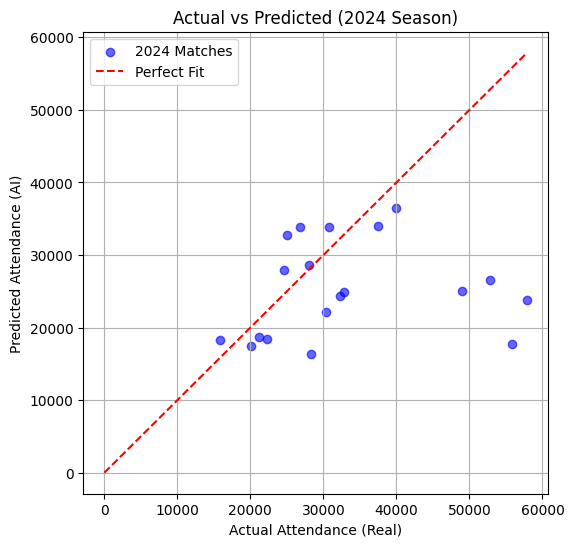

,対戦相手,スタジアム,実測値,予測値,誤差
155,広島,味スタ,32274,24382.658525,-7891.341475
156,神戸,味スタ,24974,32819.426353,7845.426353
157,浦和,国立,49005,25099.681620,-23905.318380
158,鹿島,国立,52772,26617.934952,-26154.065048
159,町田,味スタ,30811,33911.730497,3100.730497
160,京都,味スタ,26770,33911.730497,7141.730497
161,柏,味スタ,22325,18455.668545,-3869.331455
162,横浜FM,味スタ,30411,22149.376250,-8261.623750
163,Ｇ大阪,味スタ,27972,28623.769158,651.769158
164,磐田,味スタ,24580,27948.069673,3368.069673


In [32]:
# 学習
ols_model = sm.OLS(y_train, X_train).fit()

# 予測
ols_pred = ols_model.predict(X_test)

# ---------------------------------------------------------
# 5. 答え合わせ（可視化）
# ---------------------------------------------------------
# 精度スコアの計算
r2_test = r2_score(y_test, ols_pred)
rmse_test = np.sqrt(mean_squared_error(y_test, ols_pred))

print("========================================")
print(f"★ 2024年予測の精度 (R2): {r2_test:.3f}")
print(f"★ 誤差の大きさ (RMSE)  : {rmse_test:,.0f} 人")
print("========================================")

# 散布図で確認
plt.figure(figsize=(6, 6))
plt.scatter(y_test, ols_pred, color="blue", alpha=0.6, label="2024 Matches")

# 真ん中の線（ピッタリ賞のライン）
max_val = max(y_test.max(), ols_pred.max())
plt.plot([0, max_val], [0, max_val], color="red", linestyle="--", label="Perfect Fit")

plt.title("Actual vs Predicted (2024 Season)")
plt.xlabel("Actual Attendance (Real)")
plt.ylabel("Predicted Attendance (AI)")
plt.legend()
plt.grid(True)
plt.show()

# 具体的にどの試合をどう外したか見る
results_df = pd.DataFrame({
    "対戦相手": df_merged.loc[X_test.index, "アウェイ"],
    "スタジアム": df_merged.loc[X_test.index, "スタジアム"],
    "実測値": y_test,
    "予測値": ols_pred,
    "誤差": ols_pred - y_test
})
display(results_df)

In [ ]:
# 読み込み
df = pd.read_csv("J1_tokyo_home_2015-2024.csv")
# 各変数
df["コロナ禍ダミー"] = df["シーズン"].apply(lambda x: 1 if x in [2020, 2021] else 0)
df["国立フラグ"] = df["スタジアム"].str.contains("国立").astype(int)
df["試合日"] = df["試合日"].astype(str)
df["曜日"] = df["試合日"].str.extract(r"[（(]([^)）]+)[)）]")
df["休日フラグ"] = df["曜日"].str.contains("土|日|祝").astype(int)
df["rolling_mean_3"] = df["入場者数"].rolling(window=3).mean()


★ 2024年予測の精度 (R2): -1.082
★ 誤差の大きさ (RMSE)  : 17,533 人


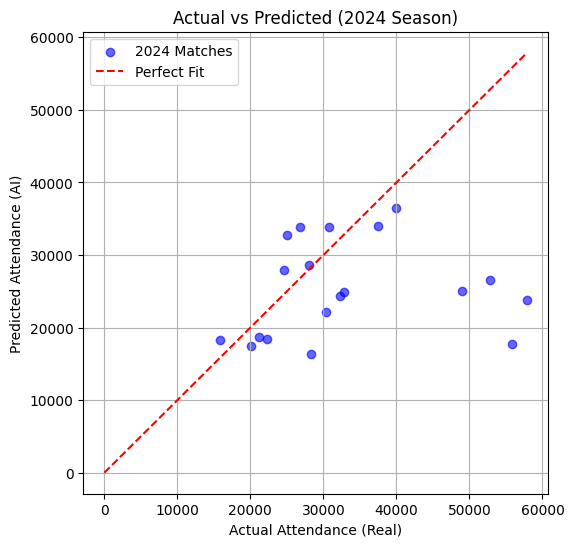

In [33]:
# RF
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score



# ランダムフォレスト回帰モデルの作成
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# モデルの学習
rf_model.fit(X_train, y_train)
# モデルの評価
rf_pred = rf_model.predict(X_test)

# ---------------------------------------------------------
# 5. 答え合わせ（可視化）
# ---------------------------------------------------------
# 精度スコアの計算
r2_test = r2_score(y_test,rf_pred)
rmse_test = np.sqrt(mean_squared_error(y_test, rf_pred))

print("========================================")
print(f"★ 2024年予測の精度 (R2): {r2_test:.3f}")
print(f"★ 誤差の大きさ (RMSE)  : {rmse_test:,.0f} 人")
print("========================================")

# 散布図で確認
plt.figure(figsize=(6, 6))
plt.scatter(y_test, ols_pred, color="blue", alpha=0.6, label="2024 Matches")

# 真ん中の線（ピッタリ賞のライン）
max_val = max(y_test.max(), ols_pred.max())
plt.plot([0, max_val], [0, max_val], color="red", linestyle="--", label="Perfect Fit")

plt.title("Actual vs Predicted (2024 Season)")
plt.xlabel("Actual Attendance (Real)")
plt.ylabel("Predicted Attendance (AI)")
plt.legend()
plt.grid(True)